### 6.3 Experiments: Architecture Ablation  
#### 6.3.1 Depth Ablation

In this experiment, we study the effect of network depth on performance.
The hidden layer width is fixed at 64 neurons, while the depth is varied
from 1 to 4 hidden layers.

For each architecture:
- Training and validation loss curves are plotted
- Training time per epoch is measured
- Overfitting is analyzed via the train–validation gap

Finally, a summary plot of MSE versus depth is presented.

In [1]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from mlp import MLP

In [2]:
# Config
PLOT_DIR = r"C:\Users\PUSHKAR\Desktop\DL-Assignments\Assignment-1\plots\mlp-experiment\depth-ablation"
os.makedirs(PLOT_DIR, exist_ok=True)

EPOCHS = 100
LR = 0.01
WIDTH = 64
DEPTHS = [1, 2, 3, 4]

In [3]:
# ----------------------------
# Load dataset
# ----------------------------
df = pd.read_csv(r"C:\Users\PUSHKAR\Desktop\DL-Assignments\Assignment-1\iit_h_mess_dataset.csv")

X = df.drop(columns=["mess_duration"]).values
y = df["mess_duration"].values.reshape(-1, 1)

In [4]:
# train / val / test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [5]:
# feature scaling (CRITICAL)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train)
y_val_scaled   = y_scaler.transform(y_val)
y_test_scaled  = y_scaler.transform(y_test)

In [6]:
# ----------------------------
# Depth ablation (PER-EPOCH, ASSIGNMENT-CORRECT)
# ----------------------------

test_losses = []
avg_time_per_epoch = []

for depth in DEPTHS:
    print(f"\nTraining depth = {depth}")

    layer_sizes = [X_train.shape[1]] + [WIDTH] * depth + [1]
    activations = ["relu"] * depth + ["linear"]

    model = MLP(
        layer_sizes=layer_sizes,
        activations=activations,
        learning_rate=LR
    )

    train_losses = []
    val_losses   = []

    start = time.time()
    N = X_train.shape[0]

    for epoch in range(EPOCHS):

        # -------- Forward (train) --------
        y_pred = model.forward(X_train)                 # (1, N)
        y_true = y_train_scaled.reshape(1, -1)
        error  = y_pred - y_true

        # -------- MSE gradient --------
        dA = (2.0 / N) * error

        # -------- Manual backprop --------
        grads_W = {}
        grads_b = {}

        for l in reversed(range(1, model.L + 1)):
            dZ = dA * model.act_deriv[l](model.Z[l])
            grads_W[l] = dZ @ model.A[l - 1].T
            grads_b[l] = np.sum(dZ, axis=1, keepdims=True)
            dA = model.W[l].T @ dZ

        # -------- Update --------
        for l in range(1, model.L + 1):
            model.W[l] -= LR * grads_W[l]
            model.b[l] -= LR * grads_b[l]

        # -------- Train metrics --------
        y_train_pred = y_scaler.inverse_transform(
            model.predict(X_train)
        )

        train_losses.append(
            np.mean((y_train_pred - y_train) ** 2)
        )

        # -------- Validation metrics --------
        y_val_pred = y_scaler.inverse_transform(
            model.predict(X_val)
        )

        val_losses.append(
            np.mean((y_val_pred - y_val) ** 2)
        )

    elapsed = time.time() - start
    avg_time = elapsed / EPOCHS
    avg_time_per_epoch.append(avg_time)

    print(f"Avg time per epoch: {avg_time:.4f}s")

    # -------- Test loss --------
    y_test_pred = y_scaler.inverse_transform(
        model.predict(X_test)
    )

    test_loss = np.mean((y_test_pred - y_test) ** 2)
    test_losses.append(test_loss)

    print(f"Final Test MSE: {test_loss:.4f}")

    # -------- Loss curves --------
    plt.figure()

    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")

    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Loss vs Epoch (Depth={depth})")

    plt.legend()

    plt.savefig(os.path.join(PLOT_DIR, f"depth_{depth}_loss.png"))
    plt.close()


Training depth = 1
Avg time per epoch: 0.0056s
Final Test MSE: 31.5250

Training depth = 2
Avg time per epoch: 0.0130s
Final Test MSE: 30.1070

Training depth = 3
Avg time per epoch: 0.0206s
Final Test MSE: 31.0579

Training depth = 4
Avg time per epoch: 0.0279s
Final Test MSE: 41.8871


In [7]:
# ----------------------------
# Summary plot
# ----------------------------
plt.figure()

plt.plot(DEPTHS, test_losses, marker="o")

plt.xlabel("Number of Hidden Layers")
plt.ylabel("Test MSE")
plt.title("Depth Ablation : Test Loss vs Network Depth")

plt.grid(True)

plt.savefig(os.path.join(PLOT_DIR, "test_loss_vs_depth.png"))
plt.close()

print("\nDepth ablation experiment completed.")
print(f"Plots saved in {PLOT_DIR}")


Depth ablation experiment completed.
Plots saved in C:\Users\PUSHKAR\Desktop\DL-Assignments\Assignment-1\plots\mlp-experiment\depth-ablation


### 6.3.2 Width Ablation

In this experiment, the network depth is fixed at **two hidden layers**, while
the **width (number of neurons per hidden layer)** is varied.

The following architectures are evaluated:
- [input, 8, 8, output]
- [input, 16, 16, output]
- [input, 32, 32, output]
- [input, 64, 64, output]
- [input, 128, 128, output]
- [input, 256, 256, output]

For each architecture:
- The model is trained using the same hyperparameters
- The total number of trainable parameters is computed

A summary plot of **test MSE vs. number of parameters (log scale)** is generated.

In [8]:
PLOT_DIR = r"C:\Users\PUSHKAR\Desktop\DL-Assignments\Assignment-1\plots\mlp-experiment\width-ablation"
os.makedirs(PLOT_DIR, exist_ok=True)

In [9]:
# ----------------------------
# Width ablation
# ----------------------------
WIDTHS = [8, 16, 32, 64, 128, 256]
DEPTH = 2
REPEATS = 3   # average over runs

test_losses = []
num_params = []

for width in WIDTHS:
    print(f"\nTraining width = {width}")

    loss_runs = []

    for run in range(REPEATS):

        layer_sizes = [X_train.shape[1], width, width, 1]
        activations = ["relu", "relu", "linear"]

        model = MLP(
            layer_sizes=layer_sizes,
            activations=activations,
            learning_rate=LR / np.sqrt(width)  # optional but principled
        )

        model.fit(X_train, y_train_scaled, epochs=EPOCHS)

        y_test_pred = y_scaler.inverse_transform(
            model.predict(X_test)
        )

        # Compute MSE
        loss = np.mean((y_test_pred - y_test) ** 2)
        loss_runs.append(loss)

    loss_mean = np.mean(loss_runs)
    test_losses.append(loss_mean)

    # -------- Parameter count --------
    params = 0
    for l in range(1, len(layer_sizes)):
        params += layer_sizes[l-1] * layer_sizes[l]
        params += layer_sizes[l]

    num_params.append(params)

    print(f"Avg Test MSE: {loss_mean:.4f}")
    print(f"Number of parameters: {params}")


Training width = 8
Avg Test MSE: 63.4936
Number of parameters: 201

Training width = 16
Avg Test MSE: 73.0522
Number of parameters: 529

Training width = 32
Avg Test MSE: 54.9474
Number of parameters: 1569

Training width = 64
Avg Test MSE: 61.6926
Number of parameters: 5185

Training width = 128
Avg Test MSE: 65.4013
Number of parameters: 18561

Training width = 256
Avg Test MSE: 63.6443
Number of parameters: 69889


In [10]:
# ----------------------------
# Summary plot
# ----------------------------
plt.figure()

plt.plot(num_params, test_losses, marker="o")

plt.xscale("log")

plt.xlabel("Number of Parameters (log scale)")
plt.ylabel("Test MSE")

plt.title("Width Ablation: Test Loss vs Model Size")

plt.grid(True)

plt.savefig(os.path.join(PLOT_DIR, "width_ablation_loss_vs_params.png"))
plt.close()

### 6.3.3 Activation Function Comparison

In this experiment, the network architecture is fixed to  
[input, 64, 64, output], and the effect of different activation
functions on training dynamics is studied.

The following configurations are compared:
- Sigmoid activations in all layers
- Tanh activations in all layers
- ReLU in hidden layers with sigmoid output
- Leaky ReLU in hidden layers with sigmoid output

For each configuration:
- Training and validation loss curves are plotted
- Gradient statistics (mean and standard deviation) are recorded
- Dead neurons are analyzed for ReLU-based networks
- Gradient magnitudes across layers are compared to study vanishing gradients

In [11]:
PLOT_DIR = r"C:\Users\PUSHKAR\Desktop\DL-Assignments\Assignment-1\plots\mlp-experiment\activation-function-comparision"
os.makedirs(PLOT_DIR, exist_ok=True)

In [12]:
# ----------------------------
# Activation Function Comparison (CLEAN & REQUIRED)
# ----------------------------

ACTIVATION_CONFIGS = {
    "sigmoid_all":          ["sigmoid", "sigmoid", "sigmoid"],
    "tanh_all":             ["tanh", "tanh", "tanh"],
    "relu_sigmoid":         ["relu", "relu", "sigmoid"],
    "leaky_relu_sigmoid":   ["leaky_relu", "leaky_relu", "sigmoid"],
}

layer_sizes = [X_train.shape[1], 64, 64, 1]

for name, activations in ACTIVATION_CONFIGS.items():
    print(f"\nTraining configuration: {name}")

    model = MLP(
        layer_sizes=layer_sizes,
        activations=activations,
        learning_rate=LR
    )

    train_losses, val_losses = [], []
    grad_means, grad_stds    = [], []

    N = X_train.shape[0]

    # ----------------------------
    # Per-epoch training
    # ----------------------------
    for epoch in range(EPOCHS):

        # ----- Forward -----
        y_pred = model.forward(X_train)
        y_true = y_train_scaled.reshape(1, -1)
        error  = y_pred - y_true

        # ----- MSE gradient -----
        dA = (2.0 / N) * error

        # ----- Manual backprop -----
        grads_W, grads_b = {}, {}

        for l in reversed(range(1, model.L + 1)):
            dZ = dA * model.act_deriv[l](model.Z[l])
            grads_W[l] = dZ @ model.A[l - 1].T
            grads_b[l] = np.sum(dZ, axis=1, keepdims=True)
            dA = model.W[l].T @ dZ

        # ----- Update -----
        for l in range(1, model.L + 1):
            model.W[l] -= LR * grads_W[l]
            model.b[l] -= LR * grads_b[l]

        # ----- Gradient statistics -----
        norms = [np.linalg.norm(grads_W[l]) for l in grads_W]
        grad_means.append(np.mean(norms))
        grad_stds.append(np.std(norms))

        # ----- Train metrics -----
        y_train_pred = y_scaler.inverse_transform(model.predict(X_train))
        train_losses.append(np.mean((y_train_pred - y_train) ** 2))

        # ----- Validation metrics -----
        y_val_pred = y_scaler.inverse_transform(model.predict(X_val))
        val_losses.append(np.mean((y_val_pred - y_val) ** 2))

    # ----------------------------
    # Loss plot
    # ----------------------------
    plt.figure()

    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")

    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Loss vs Epoch ({name})")

    plt.legend()

    plt.savefig(os.path.join(PLOT_DIR, f"loss_{name}.png"))
    plt.close()

    # ----------------------------
    # Report statistics
    # ----------------------------
    print(f"Final Train MSE: {train_losses[-1]:.2f}")
    print(f"Final Val   MSE: {val_losses[-1]:.2f}")
    print(f"Final Grad Mean: {grad_means[-1]:.3e}")
    print(f"Final Grad Std : {grad_stds[-1]:.3e}")

    # ----- Dead neuron analysis -----
    if "relu" in name:
        dead_fraction = np.mean(model.A[1] <= 0)
        print(f"Dead neuron fraction (layer 1): {dead_fraction:.4f}")


Training configuration: sigmoid_all
Final Train MSE: 74.66
Final Val   MSE: 75.07
Final Grad Mean: 5.699e-02
Final Grad Std : 4.037e-02

Training configuration: tanh_all
Final Train MSE: 29.79
Final Val   MSE: 31.06
Final Grad Mean: 7.541e-02
Final Grad Std : 1.082e-02

Training configuration: relu_sigmoid
Final Train MSE: 70.52
Final Val   MSE: 70.17
Final Grad Mean: 1.781e-01
Final Grad Std : 1.887e-02
Dead neuron fraction (layer 1): 0.4945

Training configuration: leaky_relu_sigmoid
Final Train MSE: 71.76
Final Val   MSE: 71.59
Final Grad Mean: 1.761e-01
Final Grad Std : 2.659e-02
Dead neuron fraction (layer 1): 0.4998


### 6.4 Loss Function Analysis

In this experiment, three different loss functions are evaluated for the mess
duration prediction task. The same network architecture and training
hyperparameters are used, while only the loss function is varied.

The goal is to compare convergence behavior, robustness, and final performance,
and to identify which loss function is most suitable for this regression problem.

In [13]:
PLOT_DIR = r"C:\Users\PUSHKAR\Desktop\DL-Assignments\Assignment-1\plots\mlp-experiment\loss-function-comparision"
os.makedirs(PLOT_DIR, exist_ok=True)

In [14]:
# ----------------------------
# Loss Function Analysis (CORRECTED & CONSISTENT)
# ----------------------------

LOSSES = ["mse", "mae", "huber"]
DELTA = 1.0   # Huber threshold (scaled space)

results = {}

for loss_name in LOSSES:
    print(f"\nTraining with loss = {loss_name.upper()}")

    model = MLP(
        layer_sizes=[X_train.shape[1], 64, 64, 1],
        activations=["relu", "relu", "linear"],
        learning_rate=LR
    )

    train_loss = []
    val_loss = []

    for epoch in range(EPOCHS):

        # -------- Forward --------
        y_pred = model.forward(X_train)                 # (1, N)
        y_true = y_train_scaled.reshape(1, -1)
        error = y_pred - y_true
        N = error.size

        # -------- Loss + dA --------
        if loss_name == "mse":
            dA = (2.0 / N) * error

        elif loss_name == "mae":
            dA = (1.0 / N) * np.sign(error)

        elif loss_name == "huber":
            abs_err = np.abs(error)
            dA = np.where(
                abs_err <= DELTA,
                error,
                DELTA * np.sign(error)
            ) / N

        # -------- Manual backprop from dA --------
        grads_W = {}
        grads_b = {}

        for l in reversed(range(1, model.L + 1)):
            dZ = dA * model.act_deriv[l](model.Z[l])
            grads_W[l] = dZ @ model.A[l - 1].T
            grads_b[l] = np.sum(dZ, axis=1, keepdims=True)
            dA = model.W[l].T @ dZ

        # -------- Gradient descent --------
        for l in range(1, model.L + 1):
            model.W[l] -= LR * grads_W[l]
            model.b[l] -= LR * grads_b[l]

        # -------- Evaluation (original units) --------
        y_train_pred = y_scaler.inverse_transform(
            model.predict(X_train)
        )
        y_val_pred = y_scaler.inverse_transform(
            model.predict(X_val)
        )

        train_loss.append(
            np.mean((y_train_pred - y_train) ** 2)
        )
        val_loss.append(
            np.mean((y_val_pred - y_val) ** 2)
        )

    results[loss_name] = {
        "train_loss": train_loss,
        "val_loss": val_loss
    }

    # -------- Plot --------
    plt.figure()
    plt.plot(train_loss, label="Train MSE (minutes²)")
    plt.plot(val_loss, label="Val MSE (minutes²)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curves ({loss_name.upper()})")
    plt.legend()
    plt.savefig(os.path.join(PLOT_DIR, f"loss_function_{loss_name}.png"))
    plt.close()

print("Loss function experiments completed.")


Training with loss = MSE

Training with loss = MAE

Training with loss = HUBER
Loss function experiments completed.


In [15]:
plt.figure()

for loss_name in LOSSES:
    plt.plot(
        results[loss_name]["val_loss"],
        label=loss_name.upper()
    )

plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Loss Function Comparison")
plt.legend()

plt.savefig(os.path.join(PLOT_DIR, "loss_function_comparison.png"))
plt.close()

### 6.5 Optimizer Comparison

**Approach:**
- Use best architecture from ablation: `[input, 64, 64, output]` with ReLU hidden layers
- Implement 7 optimizers from scratch (no PyTorch): **SGD, SGD+Momentum, Adam, AdaGrad, Nesterov, RMSProp, Muon**
- For each optimizer:
  - Plot **convergence curves (validation MSE vs epoch)**
  - Report **time to reach near-best validation loss**
  - Plot **weight update magnitudes per epoch**
- **Learning rate sensitivity:** sweep LR values and plot **final validation MSE vs LR** for each optimizer

In [16]:
PLOT_DIR = r"C:\Users\PUSHKAR\Desktop\DL-Assignments\Assignment-1\plots\mlp-experiment\optimizer-comparision"
os.makedirs(PLOT_DIR, exist_ok=True)

In [17]:
LAYER_SIZES = [X_train.shape[1], 64, 64, 1]
ACTIVATIONS = ["relu", "relu", "linear"]
EPOCHS_OPT  = EPOCHS
BASE_LR     = LR

# Learning rates to sweep for sensitivity analysis
LR_SWEEP = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1]

In [18]:
# ----------------------------
# Helper: train one optimizer config
# ----------------------------

def train_with_optimizer(optimizer, epochs=EPOCHS_OPT):
    model = MLP(
        layer_sizes=LAYER_SIZES,
        activations=ACTIVATIONS,
        learning_rate=optimizer.lr
    )

    optimizer.init_state(model)

    val_losses  = []
    update_mags = []
    start       = time.time()

    N = X_train.shape[0]

    for epoch in range(epochs):

        # -------- Forward --------
        y_pred = model.forward(X_train)          # (1, N)
        y_true = y_train_scaled.reshape(1, -1)
        error  = y_pred - y_true

        # -------- Normalized gradient at output --------
        dA = (2.0 / N) * error                   # correct MSE gradient

        # -------- Manual backprop --------
        grads_W = {}
        grads_b = {}

        for l in reversed(range(1, model.L + 1)):
            dZ = dA * model.act_deriv[l](model.Z[l])
            grads_W[l] = dZ @ model.A[l - 1].T
            grads_b[l] = np.sum(dZ, axis=1, keepdims=True)
            dA = model.W[l].T @ dZ

        # -------- Optimizer step --------
        updates = optimizer.step(model, grads_W, grads_b)
        update_mags.append(np.mean(list(updates.values())))

        # -------- Validation loss (MSE) --------
        y_val_pred = y_scaler.inverse_transform(
            model.predict(X_val)
        )

        val_losses.append(
            np.mean((y_val_pred - y_val) ** 2)
        )

    elapsed = time.time() - start

    return model, val_losses, update_mags, elapsed

In [19]:
from optimizers import SGD, SGDMomentum, Adam, AdaGrad, Nesterov, RMSProp, Muon

In [20]:
# ----------------------------
# Run all optimizers
# ----------------------------

OPTIMIZERS = {
    "SGD":          SGD(lr=BASE_LR),
    "SGD+Momentum": SGDMomentum(lr=BASE_LR, beta=0.9),
    "Adam":         Adam(lr=BASE_LR, beta1=0.9, beta2=0.999, eps=1e-8),
    "AdaGrad":      AdaGrad(lr=BASE_LR),
    "Nesterov":     Nesterov(lr=BASE_LR, beta=0.9),
    "RMSProp":      RMSProp(lr=BASE_LR),
    "Muon":         Muon(lr=BASE_LR),
}

all_val_losses  = {}
all_update_mags = {}
time_to_near_best = {}

In [21]:
# Check shapes
print("X_train shape:", X_train.shape)
print("y_train_scaled shape:", y_train_scaled.shape)

# Check a single forward pass
test_model = MLP(layer_sizes=LAYER_SIZES, activations=ACTIVATIONS, learning_rate=BASE_LR)
out = test_model.forward(X_train)
print("Model output shape:", out.shape)
print("Output sample:", out[:, :5])

X_train shape: (3500, 14)
y_train_scaled shape: (3500, 1)
Model output shape: (1, 3500)
Output sample: [[-0.60670763  0.2176502  -0.32488217 -0.53742083 -0.47983022]]


In [22]:
for opt_name, optimizer in OPTIMIZERS.items():
    print(f"\nTraining with {opt_name} ...")

    model, val_losses, update_mags, elapsed = train_with_optimizer(optimizer)

    all_val_losses[opt_name]  = val_losses
    all_update_mags[opt_name] = update_mags

    # -------- Time to reach near-best validation loss --------
    best_loss  = min(val_losses)
    threshold  = best_loss * 1.1      # within 10% of best loss

    epochs_arr = [i for i, l in enumerate(val_losses) if l <= threshold]
    t_epoch    = epochs_arr[0] if epochs_arr else EPOCHS_OPT

    time_to_near_best[opt_name] = t_epoch

    print(f"  Best val loss : {best_loss:.4f}")
    print(f"  Epoch to near-best : {t_epoch}")
    print(f"  Total time   : {elapsed:.2f}s")


Training with SGD ...
  Best val loss : 29.3063
  Epoch to near-best : 68
  Total time   : 0.96s

Training with SGD+Momentum ...
  Best val loss : 20.8894
  Epoch to near-best : 67
  Total time   : 1.02s

Training with Adam ...
  Best val loss : 8.0495
  Epoch to near-best : 94
  Total time   : 1.01s

Training with AdaGrad ...
  Best val loss : 13.1559
  Epoch to near-best : 79
  Total time   : 1.03s

Training with Nesterov ...
  Best val loss : 20.4406
  Epoch to near-best : 63
  Total time   : 1.43s

Training with RMSProp ...
  Best val loss : 15.5586
  Epoch to near-best : 73
  Total time   : 1.13s

Training with Muon ...
  Best val loss : 14.4439
  Epoch to near-best : 83
  Total time   : 1.07s


In [23]:
# ----------------------------
# Plot 1: Convergence curves
# ----------------------------
plt.figure(figsize=(10, 5))

for opt_name, val_losses in all_val_losses.items():
    plt.plot(val_losses, label=opt_name)

plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Convergence Curves — All Optimizers")

plt.legend()
plt.grid(True)

plt.savefig(os.path.join(PLOT_DIR, "optimizer_convergence.png"))
plt.close()


# ----------------------------
# Plot 2: Time to near-best validation loss
# ----------------------------
plt.figure(figsize=(8, 4))

plt.bar(time_to_near_best.keys(), time_to_near_best.values())

plt.xlabel("Optimizer")
plt.ylabel("Epoch")
plt.title("Epochs to Reach Near-Best Validation Loss")

plt.grid(True, axis="y")

plt.savefig(os.path.join(PLOT_DIR, "optimizer_time_to_near_best.png"))
plt.close()


# ----------------------------
# Plot 3: Weight update magnitudes
# ----------------------------
plt.figure(figsize=(10, 5))

for opt_name, mags in all_update_mags.items():
    plt.plot(mags, label=opt_name)

plt.xlabel("Epoch")
plt.ylabel("Mean |Weight Update|")
plt.title("Weight Update Magnitudes — All Optimizers")

plt.legend()
plt.grid(True)

plt.savefig(os.path.join(PLOT_DIR, "optimizer_update_magnitudes.png"))
plt.close()

In [24]:
# ----------------------------
# Plot 4: LR sensitivity
# ----------------------------

lr_results = {opt_name: [] for opt_name in OPTIMIZERS}

for lr_val in LR_SWEEP:
    print(f"\nLR sweep: lr = {lr_val}")

    sweep_opts = {
        "SGD":          SGD(lr=lr_val),
        "SGD+Momentum": SGDMomentum(lr=lr_val, beta=0.9),
        "Adam":         Adam(lr=lr_val, beta1=0.9, beta2=0.999, eps=1e-8),
        "AdaGrad":      AdaGrad(lr=lr_val),
        "Nesterov":     Nesterov(lr=lr_val, beta=0.9),
        "RMSProp":      RMSProp(lr=lr_val),
        "Muon":         Muon(lr=lr_val),
    }

    for opt_name, optimizer in sweep_opts.items():

        _, val_losses, _, _ = train_with_optimizer(optimizer)

        lr_results[opt_name].append(val_losses[-1])   # final validation MSE


plt.figure(figsize=(10, 5))

for opt_name, losses in lr_results.items():
    plt.plot(LR_SWEEP, losses, marker="o", label=opt_name)

plt.xscale("log")

plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Final Validation MSE")
plt.title("LR Sensitivity — All Optimizers")

plt.legend()
plt.grid(True)

plt.savefig(os.path.join(PLOT_DIR, "optimizer_lr_sensitivity.png"))
plt.close()

print("\nOptimizer comparison completed.")


LR sweep: lr = 0.0001

LR sweep: lr = 0.0005

LR sweep: lr = 0.001

LR sweep: lr = 0.005

LR sweep: lr = 0.01

LR sweep: lr = 0.05

LR sweep: lr = 0.1

Optimizer comparison completed.


In [25]:
# After training, find first epoch where val_loss is within 10% of best loss

best_loss   = min(val_losses)
best_epoch  = val_losses.index(best_loss)

threshold   = best_loss * 1.1   # within 10% of best

# Find first epoch to reach threshold
epochs_arr = [i for i, l in enumerate(val_losses) if l <= threshold]
t_epoch    = epochs_arr[0] if epochs_arr else EPOCHS_OPT

time_to_near_best[opt_name] = t_epoch

print(f"  Best val loss : {best_loss:.4f} at epoch {best_epoch}")
print(f"  Epoch to near-best : {t_epoch}")

  Best val loss : 3.1014 at epoch 91
  Epoch to near-best : 83


In [26]:
print("EPOCHS:", EPOCHS)
print("BASE_LR:", BASE_LR)
print("y_train sample:", y_train[:5])
print("y_train_scaled sample:", y_train_scaled[:5])

# Check if validation loss changes across epochs
test_opt = SGD(lr=BASE_LR)

_, val_losses, _, _ = train_with_optimizer(test_opt, epochs=EPOCHS)

print("Val loss first 10 epochs:", val_losses[:10])
print("Val loss last 10 epochs:", val_losses[-10:])

EPOCHS: 100
BASE_LR: 0.01
y_train sample: [[14.34091929]
 [17.13597181]
 [24.24382017]
 [30.58929326]
 [23.38883705]]
y_train_scaled sample: [[-1.26706987]
 [-0.94117031]
 [-0.11240424]
 [ 0.62746983]
 [-0.21209419]]
Val loss first 10 epochs: [np.float64(82.14250660661921), np.float64(78.77727009499293), np.float64(75.97911541635744), np.float64(73.60841308358967), np.float64(71.56438363560862), np.float64(69.77207314466058), np.float64(68.17211085748853), np.float64(66.72395591859598), np.float64(65.39816710330012), np.float64(64.17088551373672)]
Val loss last 10 epochs: [np.float64(30.322578654533466), np.float64(30.19701614193395), np.float64(30.073985664729562), np.float64(29.953490720888716), np.float64(29.835777778097274), np.float64(29.72045703925941), np.float64(29.607673653953068), np.float64(29.497419242157658), np.float64(29.389463368695818), np.float64(29.283936856363812)]


### 6.6 Regularization

**Approach:**
- Implement **L1 and L2 regularization** by adding penalty gradients manually during the backward pass.
- Compare 7 configurations: **no regularization**, **L1** ($\lambda = 0.001, 0.01, 0.1$), and **L2** ($\lambda = 0.001, 0.01, 0.1$).
- For each configuration: plot **training vs validation MSE curves**.
- For **L1 regularization**: plot **weight sparsity** (fraction of weights with $|w| < 10^{-3}$) vs $\lambda$.

In [27]:
PLOT_DIR = r"C:\Users\PUSHKAR\Desktop\DL-Assignments\Assignment-1\plots\mlp-experiment\regularization-comparision"
os.makedirs(PLOT_DIR, exist_ok=True)

In [28]:
L1_LAMBDAS = [0.001, 0.01, 0.1]
L2_LAMBDAS = [0.001, 0.01, 0.1]

REG_CONFIGS = (
    [("none", 0.0)]
    + [("l1", lam) for lam in L1_LAMBDAS]
    + [("l2", lam) for lam in L2_LAMBDAS]
)

l1_sparsity = []   # for sparsity plot
l1_lambdas_used = []

In [29]:
# ----------------------------
# Regularization comparison (CORRECTED)
# ----------------------------

for reg_type, lam in REG_CONFIGS:
    label = f"{reg_type}_lambda={lam}" if reg_type != "none" else "no_reg"
    print(f"\nTraining: {label}")

    model = MLP(
        layer_sizes=LAYER_SIZES,
        activations=ACTIVATIONS,
        learning_rate=LR
    )

    train_losses = []
    val_losses   = []

    N = X_train.shape[0]

    for epoch in range(EPOCHS):

        # -------- Forward --------
        y_pred = model.forward(X_train)                 # (1, N)
        y_true = y_train_scaled.reshape(1, -1)
        error  = y_pred - y_true

        # -------- Correct MSE gradient --------
        dA = (2.0 / N) * error

        # -------- Manual backprop --------
        grads_W = {}
        grads_b = {}

        for l in reversed(range(1, model.L + 1)):
            dZ = dA * model.act_deriv[l](model.Z[l])
            grads_W[l] = dZ @ model.A[l - 1].T
            grads_b[l] = np.sum(dZ, axis=1, keepdims=True)
            dA = model.W[l].T @ dZ

        # -------- Regularization + update --------
        for l in range(1, model.L + 1):

            if reg_type == "l1":
                reg_grad = lam * np.sign(model.W[l])
            elif reg_type == "l2":
                reg_grad = lam * model.W[l]
            else:
                reg_grad = 0.0

            model.W[l] -= LR * (grads_W[l] + reg_grad)
            model.b[l] -= LR * grads_b[l]

        # -------- Loss (MSE) --------
        y_train_pred = y_scaler.inverse_transform(
            model.predict(X_train)
        )
        y_val_pred = y_scaler.inverse_transform(
            model.predict(X_val)
        )

        train_losses.append(
            np.mean((y_train_pred - y_train) ** 2)
        )

        val_losses.append(
            np.mean((y_val_pred - y_val) ** 2)
        )

    # -------- Plot train vs val loss --------
    plt.figure()

    plt.plot(train_losses, label="Train MSE")
    plt.plot(val_losses,   label="Val MSE")

    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Train vs Val Loss ({label})")

    plt.legend()
    plt.grid(True)

    plt.savefig(os.path.join(PLOT_DIR, f"reg_{label}_loss.png"))
    plt.close()

    print(f"  Final val loss: {val_losses[-1]:.4f}")

    # -------- L1 sparsity --------
    if reg_type == "l1":
        all_weights = np.concatenate([
            model.W[l].flatten()
            for l in range(1, model.L + 1)
        ])

        sparsity = np.mean(np.abs(all_weights) < 1e-3)

        l1_sparsity.append(sparsity)
        l1_lambdas_used.append(lam)

        print(f"  Weight sparsity (|w| < 1e-3): {sparsity:.4f}")


Training: no_reg
  Final val loss: 30.1677

Training: l1_lambda=0.001
  Final val loss: 29.2620
  Weight sparsity (|w| < 1e-3): 0.0077

Training: l1_lambda=0.01
  Final val loss: 29.3791
  Weight sparsity (|w| < 1e-3): 0.0508

Training: l1_lambda=0.1
  Final val loss: 52.3187
  Weight sparsity (|w| < 1e-3): 0.4428

Training: l2_lambda=0.001
  Final val loss: 34.0546

Training: l2_lambda=0.01
  Final val loss: 30.8443

Training: l2_lambda=0.1
  Final val loss: 32.5161


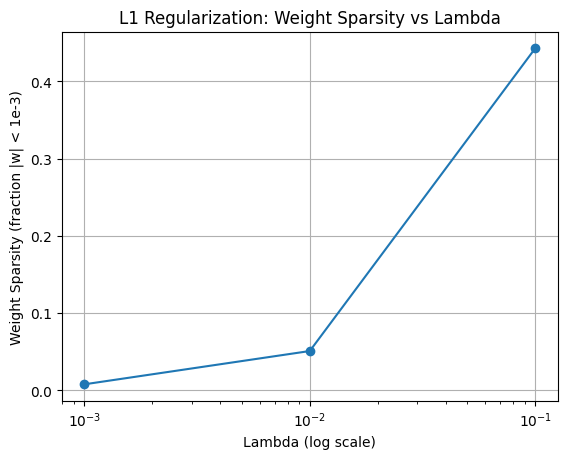


Regularization experiments completed.


In [30]:
# ----------------------------
# L1 Sparsity vs Lambda plot
# ----------------------------
plt.figure()
plt.plot(l1_lambdas_used, l1_sparsity, marker="o")
plt.xscale("log")
plt.xlabel("Lambda (log scale)")
plt.ylabel("Weight Sparsity (fraction |w| < 1e-3)")
plt.title("L1 Regularization: Weight Sparsity vs Lambda")
plt.grid(True)
plt.savefig(os.path.join(PLOT_DIR, "l1_sparsity_vs_lambda.png"))
plt.show()
plt.close()

print("\nRegularization experiments completed.")

## 6.7 Success Analysis

**Approach:**
- Extract hidden layer activations from best MLP, project to 2D with PCA, color by binned target (class label proxy)
- Train Adaline (single-layer linear model with MSE) on same data
- Compare MLP vs Adaline: test MSE, training time in a summary table

In [31]:
from sklearn.decomposition import PCA
import sys
sys.path.append(r"C:\Users\PUSHKAR\Desktop\DL-Assignments\Assignment-1\adaline")
from adaline import Adaline

In [32]:
# -------------------------------------------------------
# a) PCA Visualisation of Hidden Layer Activations
# ------------------------------------------------------

# Train best MLP (depth=2, width=64)
best_model = MLP(
    layer_sizes=LAYER_SIZES,
    activations=ACTIVATIONS,
    learning_rate=LR
)

mlp_start = time.time()
for epoch in range(EPOCHS):
    y_pred_scaled    = best_model.forward(X_train).T
    error            = y_pred_scaled - y_train_scaled
    dA               = (error / X_train.shape[0]).T
    grads_W, grads_b = best_model.backward(X_train, dA)
    for l in range(1, best_model.L + 1):
        best_model.W[l] -= LR * grads_W[l]
        best_model.b[l] -= LR * grads_b[l]
mlp_train_time = time.time() - mlp_start

In [33]:
# Extract penultimate layer activations on test set
# Forward pass stores activations in best_model.A
_ = best_model.forward(X_test)
penultimate_layer = best_model.L - 1          # last hidden layer index
hidden_activations = best_model.A[penultimate_layer].T   # (n_test, width)

# Project to 2D with PCA
pca = PCA(n_components=2)
activations_2d = pca.fit_transform(hidden_activations)

# Use mess duration bins as class labels for colouring
n_bins  = 5
labels  = pd.cut(y_test.flatten(), bins=n_bins, labels=False)

In [34]:
PLOT_DIR = r"C:\Users\PUSHKAR\Desktop\DL-Assignments\Assignment-1\plots\mlp-experiment"
os.makedirs(PLOT_DIR, exist_ok=True)

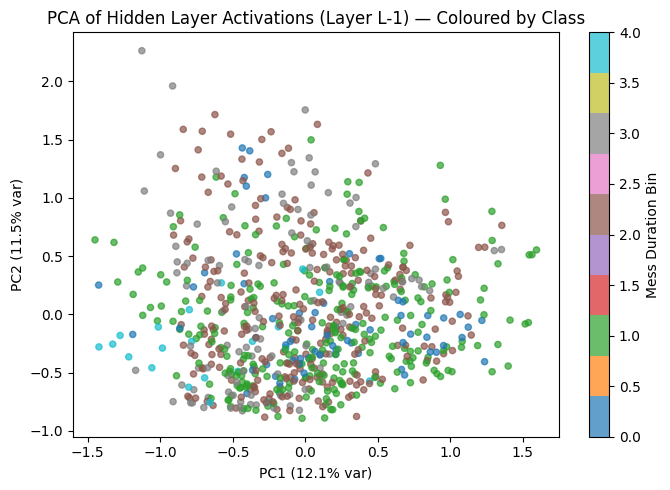

PCA explained variance: 23.6% (2 components)


In [35]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    activations_2d[:, 0], activations_2d[:, 1],
    c=labels, cmap="tab10", alpha=0.7, s=20
)
plt.colorbar(scatter, label="Mess Duration Bin")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA of Hidden Layer Activations (Layer L-1) — Coloured by Class")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "6_7_pca_activations.png"))
plt.show()
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}% (2 components)")

In [36]:
# ----------------------------
# b) Adaline
# ----------------------------

# Adaline expects y as (n_samples,) — flatten
adaline_start = time.time()

adaline = Adaline(learning_rate=LR, max_iterations=EPOCHS)
adaline.fit(X_train, y_train_scaled.flatten())

adaline_train_time = time.time() - adaline_start

# Predictions — inverse transform
adaline_test_pred = y_scaler.inverse_transform(
    adaline.predict(X_test).reshape(-1, 1)
)

mlp_test_pred = y_scaler.inverse_transform(
    best_model.predict(X_test)
)

# -------- Metrics --------
adaline_mse = np.mean((adaline_test_pred - y_test) ** 2)
mlp_mse     = np.mean((mlp_test_pred - y_test) ** 2)

In [37]:
# ----------------------------
# Comparison table
# ----------------------------
comparison = pd.DataFrame({
    "Model":          ["Adaline", "MLP [input,64,64,output]"],
    "Test MSE":       [f"{adaline_mse:.2f}", f"{mlp_mse:.2f}"],
    "Train Time (s)": [f"{adaline_train_time:.3f}", f"{mlp_train_time:.3f}"],
})

display(comparison)

print("\nSuccess analysis completed.")

,Model,Test MSE,Train Time (s)
0,Adaline,27.54,0.005
1,"MLP [input,64,64,output]",74.78,1.019



Success analysis completed.
